# In-jet heavy-quark EECs in pA: GBW and MV

**Observable:** the energy-weighted $Q\bar Q$ angular distribution per jet containing a
$Q\bar Q$ pair, at fixed $y_J,p_T$, and $R_{pA}^{\rm EEC}=C_A/C_p$.
<!-- This implements Eqs. (29), (37)–(44), and (47) of **In_jet_EECs-10.pdf**. -->

**Start here:** edit `PHYSICS`, `NUMERICS`, and `MODEL` in the first code cell, then **Run All**.
`COMPARE_MODELS=True` displays both models. The notebook is self-contained; no PDF, LHAPDF,
external Python module, or network connection is needed to run it once its Python packages are installed.
Outputs are also written to `eec_results/` next to the notebook when launched from this folder.

The saved run uses forward charm jets with $p_T=25$ GeV, $y_J=3$, $R_J=0.6$,
$\sqrt{s_{NN}}=5020$ GeV, $A=208$, and nuclear geometry factors $c=0.5$ and $c=1.0$.
The scan includes both target scales; the predicted **conditional** nuclear modification is modest.
The notebook displays numerical errors and a transverse-momentum comparison rather than assuming
that the full observable must have a large saturation signal.

## 1. Definition and assumptions

Set $b=z(1-z)$ and $\mathbf P=p_T\hat{\mathbf x}$. With one unordered $Q\bar Q$ pair per jet,

$$C_X(R)=\frac{\Theta(R_J-R)R\int dz\,b^3
\int_0^{2\pi}d\phi\,\mathcal I_X(\mathbf P,bp_TR\hat{\mathbf e}_\phi;z)}
{\int_0^{R_J}dR'\,R'\int dz\,b^2
\int_0^{2\pi}d\phi\,\mathcal I_X(\mathbf P,bp_TR'\hat{\mathbf e}_\phi;z)}.$$

This is the EEC after integrating $k\,dk$ against its scalar delta function.
The denominator is **unweighted**. Consequently $\int C_X\,dR=\langle z(1-z)\rangle\le1/4$,
not one. The nuclear ratio has **no extra $1/A$**. The value exactly at $R=0$ is zero;
its ratio is a $0/0$ limit, so the plotted scan starts at positive $R$.

Assumptions retained from the notes:

- $R_{12}\simeq k/[z(1-z)p_T]$, $E_1E_2/E_J^2\simeq z(1-z)$, and massless jet kinematics
  $x_{p,t}=p_Te^{\pm y_J}/\sqrt{s_{NN}}$. The heavy-quark mass is retained in the splitting kernel.
- The common PDF, fixed-scale coupling, area, and production prefactors cancel separately at fixed
  $y_J,p_T$. These are not absolute cross sections or finite-bin predictions.
- A homogeneous, isotropic target and the deterministic product
  $\langle F_X(\mathbf q)F_X(\mathbf q-\mathbf P)\rangle=F_X(q)F_X(|\mathbf q-\mathbf P|)$
  are used. Target fluctuations/correlations beyond this product are not included.
- Both heavy particles must be in the same jet, $R<R_J$. The default $z$ range is the notes' full
  $(0,1)$ interval. Can be justified with kinematic arguments.
- MV uses the **same GBW estimate of the parameter $Q_s(x)$**, without BK evolution.
  This is a model study, not a precise phenomenological prediction.

## 2. Parameters and packages

Requires Python 3.10+ and NumPy, SciPy, Matplotlib, and pandas; Jupyter executes the notebook.
If needed, run `%pip install numpy scipy matplotlib pandas jupyterlab` in your chosen environment.
The delivered notebook was executed using the versions printed below.

`power=18` uses $2^{18}$ points per scramble; `repeats=8` estimates integration uncertainty.
For quick exploration use `Numerics(power=15, repeats=4, n_R=32)` and turn off the optional scans.
For final plots increase `power` and repeat the convergence checks.

In [ ]:
get_ipython().run_line_magic('matplotlib', 'inline')
from IPython.display import display
from dataclasses import dataclass, replace, asdict
from functools import lru_cache
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from scipy.fft import fht, fhtoffset
from scipy.integrate import quad, simpson
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq
from scipy.special import j0, ndtri
from scipy.stats import qmc


@dataclass(frozen=True)
class Physics:
    sqrt_s: float = 5020.0       # nucleon-nucleon CM energy [GeV]
    y_J: float = 3.0             # positive rapidity = proton-going direction
    p_T: float = 25.0            # infinitesimal jet bin [GeV]
    m_Q: float = 1.3             # charm mass [GeV], fixed phenomenological input
    R_J: float = 0.6
    A: float = 208.0             # Pb
    c_nuclear: float = 0.75      # Accounts for nuclear geometry, vary over 0.5--1.0
    Qs0_sq: float = 1.0          # [GeV^2]
    x0: float = 3.04e-4
    lambda_s: float = 0.29
    Lambda_QCD: float = 0.2       # [GeV]
    z_min: float = 0.0           # 0 reproduces the notes; same cut in both integrals

    def __post_init__(self):
        if not (self.sqrt_s > 0 and self.p_T > 0 and self.m_Q > 0):
            raise ValueError('sqrt_s, p_T and m_Q must be positive.')
        if not (0 < self.R_J <= 1 and 0 <= self.z_min < 0.5):
            raise ValueError('Use 0 < R_J <= 1 and 0 <= z_min < 0.5.')
        if min(self.A, self.c_nuclear, self.Qs0_sq, self.x0, self.Lambda_QCD) <= 0:
            raise ValueError('Target and dipole parameters must be positive.')
        if not (0 < self.x_p < 1 and 0 < self.x_t < 1):
            raise ValueError('The selected kinematics give an unphysical momentum fraction.')

    @property
    def x_p(self):
        return self.p_T * np.exp(self.y_J) / self.sqrt_s

    @property
    def x_t(self):
        return self.p_T * np.exp(-self.y_J) / self.sqrt_s

    def Qs(self, target):
        if target not in ('p', 'A'):
            raise ValueError("target must be 'p' or 'A'")
        enhancement = 1.0 if target == 'p' else self.c_nuclear * self.A**(1/3)
        return np.sqrt(self.Qs0_sq * (self.x0/self.x_t)**self.lambda_s * enhancement)


@dataclass(frozen=True)
class Numerics:
    power: int = 18              # 2**power points in each independent Sobol scramble
    repeats: int = 8             # uncertainty from independent scrambles
    n_R: int = 48                # Gauss-Legendre nodes for the jet-rate denominator
    seed: int = 260922
    fft_n: int = 16384           # MV Hankel table

    def __post_init__(self):
        if self.power < 5 or self.repeats < 2 or self.n_R < 8 or self.fft_n < 1024:
            raise ValueError('Numerical settings are too small for this solver.')


PHYSICS = Physics()
NUMERICS = Numerics()
MODEL = 'MV'                    # 'GBW' or 'MV'
COMPARE_MODELS = True           # False runs only MODEL
RUN_PARAMETER_SCAN = True
RUN_CONVERGENCE = True
R_L = np.geomspace(0.008, PHYSICS.R_J, 65)
OUTPUT = Path('eec_results')
OUTPUT.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 115, 'savefig.dpi': 180, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.2,
})

In [2]:
import sys, scipy, matplotlib
print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__, '| SciPy:', scipy.__version__,
      '| Matplotlib:', matplotlib.__version__, '| pandas:', pd.__version__)
print('Common prefactors cancel: PDFs, alpha_s and target areas are not needed.')

Python: 3.12.4
NumPy: 1.26.4 | SciPy: 1.13.1 | Matplotlib: 3.8.4 | pandas: 2.2.2
Common prefactors cancel: PDFs, alpha_s and target areas are not needed.


## 3. Interchangeable dipoles

The Fourier convention is $F(q)=\int_0^\infty dr\,rJ_0(qr)S(r)/(2\pi)$, so
$\int d^2q\,F(q)=S(0)=1$. The implemented models are

$$S_{\rm GBW}(r)=e^{-r^2Q_s^2/4},\qquad
F_{\rm GBW}(q)=\frac{e^{-q^2/Q_s^2}}{\pi Q_s^2},$$
$$S_{\rm MV}(r)=\exp\left[-\frac{r^2Q_s^2}{4}
\ln\left(e+\frac1{r\Lambda}\right)\right],\quad \Lambda=0.2\ {\rm GeV},$$
$$Q_{s,p}^2(x_t)=Q_{s,0}^2(x_0/x_t)^\lambda,\qquad
Q_{s,A}^2=cA^{1/3}Q_{s,p}^2.$$

MV is transformed with FFTLog, using a subtracted analytic Gaussian and positive log interpolation.
Below $10^{-3}Q_s$ it uses the moment expansion; beyond approximately $10^3Q_s$ it continues
smoothly as $q^{-4}$. The asymptotic coefficient, transform normalization, direct Bessel quadrature,
and the contribution from this remote tail are checked below. Negative transform values raise an
error; they are not silently clipped.

For MV the input $Q_s$ differs from a saturation scale defined from a fixed value of $S$.
For scale diagnostics only, define $Q_{\rm op}$ by $S(2/Q_{\rm op})=e^{-1}$.
It equals $Q_s$ for GBW and is larger for MV. **The code still uses the requested GBW $Q_s$
parameter in the MV exponent**; $Q_{\rm op}$ only helps interpret the scan.

In [ ]:
class GBWDipole:
    name = 'GBW'

    def __init__(self, Qs, Lambda=0.2, fft_n=16384):
        self.Qs = float(Qs)

    def S(self, r):
        r = np.asarray(r, dtype=float)
        return np.exp(-r*r*self.Qs**2/4)

    def F(self, q):
        q = np.asarray(q, dtype=float)
        return np.exp(-q*q/self.Qs**2)/(np.pi*self.Qs**2)

    def log_F(self, q):
        return -np.asarray(q)**2/self.Qs**2 - np.log(np.pi*self.Qs**2)

    @property
    def Q_operational(self):
        # Defined by S(2/Q_operational) = exp(-1).
        return self.Qs


class MVDipole:
    name = 'MV'

    def __init__(self, Qs, Lambda=0.2, fft_n=16384):
        self.Qs, self.Lambda = float(Qs), float(Lambda)
        Q = self.Qs
        r = np.geomspace(1e-9/Q, 1e3/Q, fft_n)
        dln = np.log(r[1]/r[0])
        bias = 0.5
        offset = fhtoffset(dln, mu=0, initial=0, bias=bias)
        q = np.exp(offset)/r[::-1]
        # Subtract a smooth Gaussian and transform it analytically. This reduces
        # cancellation/ringing without changing the coordinate-space MV model.
        a = Q**2/4 * np.log(np.e + Q/self.Lambda)
        residual = r*(self.S(r) - np.exp(-a*r*r))
        fq = (fht(residual, dln, mu=0, offset=offset, bias=bias)/(2*np.pi*q)
              + np.exp(-q*q/(4*a))/(4*np.pi*a))
        keep = (q >= 1e-3*Q) & (q <= 1e3*Q)
        self.q_grid, self.f_grid = q[keep], fq[keep]
        if np.any(~np.isfinite(self.f_grid)) or np.any(self.f_grid <= 0):
            raise ArithmeticError('MV transform lost positivity; refine the Hankel grid.')
        self.q_min, self.q_max = self.q_grid[[0, -1]]
        self._log_interp = PchipInterpolator(np.log(self.q_grid), np.log(self.f_grid))
        def moment(power):
            def integrand(t):
                if t == 0:
                    return 0.0
                return t**power*np.exp(-t*t/4*np.log(np.e+Q/(self.Lambda*t)))
            return quad(integrand, 0, 30, epsabs=1e-12, epsrel=2e-11)[0]
        self.F0 = moment(1)/(2*np.pi*Q**2)
        self.curvature = moment(3)/(8*np.pi*Q**4)
        self.tail_coefficient_ratio = self.f_grid[-1]*2*np.pi*self.q_max**4/Q**2

    def S(self, r):
        r = np.asarray(r, dtype=float)
        rr = np.maximum(r, np.finfo(float).tiny)
        logarithm = np.logaddexp(1.0, -np.log(rr)-np.log(self.Lambda))
        return np.exp(-r*r*self.Qs**2/4*logarithm)

    def F(self, q):
        q = np.abs(np.asarray(q, dtype=float))
        safe = np.clip(q, self.q_min, self.q_max)
        interpolated = np.exp(self._log_interp(np.log(safe)))
        # Taylor series only below 10^-3 Qs. At very high q use a continuous
        # q^-4 continuation; its coefficient and weight are explicitly checked.
        low = self.F0 - self.curvature*q*q
        high = self.f_grid[-1]*(self.q_max/np.maximum(q, self.q_min))**4
        return np.where(q < self.q_min, low,
                        np.where(q > self.q_max, high, interpolated))

    def log_F(self, q):
        return np.log(self.F(q))

    @property
    def Q_operational(self):
        return brentq(lambda Q: Q*Q-self.Qs**2*np.log(np.e+Q/(2*self.Lambda)),
                      self.Qs, 100*self.Qs)


# To add a model: implement S(r), F(q), log_F(q), Q_operational and Qs,
# then register its constructor here. Non-GBW models use generic importance sampling.
DIPOLE_MODELS = {'GBW': GBWDipole, 'MV': MVDipole}


@lru_cache(maxsize=64)
def make_dipole(model, Qs, Lambda=0.2, fft_n=16384):
    if model not in DIPOLE_MODELS:
        raise ValueError(f'Unknown dipole {model!r}; choose {list(DIPOLE_MODELS)}')
    return DIPOLE_MODELS[model](Qs, Lambda, fft_n)


def scale_table(cfg, numerics):
    rows = []
    for model in DIPOLE_MODELS:
        for target in ('p', 'A'):
            d = make_dipole(model, cfg.Qs(target), cfg.Lambda_QCD, numerics.fft_n)
            rows.append(dict(model=model, target=target, x_p=cfg.x_p, x_t=cfg.x_t,
                             Qs_GeV=d.Qs, Q_operational_GeV=d.Q_operational,
                             R_Qs=4*d.Qs/cfg.p_T,
                             R_operational=4*d.Q_operational/cfg.p_T))
    return pd.DataFrame(rows)

In [4]:
scales = scale_table(PHYSICS, NUMERICS)
display(scales.round(6))
print(f'p_J^+/p_T = {np.exp(PHYSICS.y_J)/np.sqrt(2):.2f}')
print(f'4 m_Q / p_T = {4*PHYSICS.m_Q/PHYSICS.p_T:.3f}')
print(f'k at z=1/2 spans {PHYSICS.p_T*R_L[0]/4:.3f}'
      f' to {PHYSICS.p_T*R_L[-1]/4:.3f} GeV')
print(f'M_J^2/p_T^2 at z=1/2, R=R_J: '
      f'{4*PHYSICS.m_Q**2/PHYSICS.p_T**2 + PHYSICS.R_J**2/4:.3f}')
if PHYSICS.x_t >= 0.01:
    warnings.warn('x_t is outside the intended small-x region.')
if np.exp(PHYSICS.y_J)/np.sqrt(2) < 5:
    warnings.warn('The forward-energy approximation needs attention at this rapidity.')
if np.any(scales.R_operational > PHYSICS.R_J):
    print('Some operational saturation angles lie above R_J; inspect the scale table.')
scales.to_csv(OUTPUT/'scales.csv', index=False)

,model,target,x_p,x_t,Qs_GeV,Q_operational_GeV,R_Qs,R_operational
0,GBW,p,0.100028,0.000248,1.029996,1.029996,0.164799,0.164799
1,GBW,A,0.100028,0.000248,2.171251,2.171251,0.347400,0.347400
2,MV,p,0.100028,0.000248,1.029996,1.391020,0.164799,0.222563
3,MV,A,0.100028,0.000248,2.171251,3.371510,0.347400,0.539442


p_J^+/p_T = 14.20
4 m_Q / p_T = 0.208
k at z=1/2 spans 0.050 to 3.750 GeV
M_J^2/p_T^2 at z=1/2, R=R_J: 0.101


The default bin gives $x_p\simeq0.100$, $x_t\simeq2.48\times10^{-4}$,
$Q_{s,p}\simeq1.03$ GeV and $Q_{s,A}\simeq2.17$ GeV.
For $z=1/2$, the nominal saturation angles are $0.165$ and $0.347$.
The MV operational angles are approximately $0.223$ and $0.539$, also inside $R_J=0.6$.
The charm-mass angle is approximately $0.208$.

These are **scale guides**, not a claim that the full answer is a function of $k/Q_s$ alone:
the kernel also samples $\mathbf l=\mathbf k+z\mathbf P-\mathbf q$.
At other $z$ the corresponding angle is $Q/[z(1-z)p_T]$ and is larger.
The $R_J=0.6$ choice makes the transition accessible but is still a leading collinear approximation;
the mass and endpoint diagnostics below quantify part of its limitations.

## 4. Stable evaluation of the full combined kernel

Use $\mathbf q=z\mathbf P+\mathbf k-\mathbf l$. Then
$$\mathcal I_X(\mathbf P,\mathbf k;z)=\int d^2q\,
F_X(q)F_X(|\mathbf q-\mathbf P|)
K(\mathbf k,\mathbf k+z\mathbf P-\mathbf q;z).$$
Define $\mathcal C_X(P)=\int d^2q\,F_X(q)F_X(|\mathbf q-\mathbf P|)$ and
$\rho_X(\mathbf q|\mathbf P)=F_X(q)F_X(|\mathbf q-\mathbf P|)/\mathcal C_X(P)$.
The scalar $\mathcal C_X(P)$ cancels in each conditional EEC. Thus it is enough to average
the **full positive combined kernel** against $\rho_X$; interference is retained.

For GBW this is exact:
$$\mathcal C_X(P)=\frac{e^{-P^2/(2Q_s^2)}}{2\pi Q_s^2},\qquad
\rho_X=\frac{2}{\pi Q_s^2}e^{-2|\mathbf q-\mathbf P/2|^2/Q_s^2}.$$
We draw $\mathbf q=\mathbf P/2+(Q_s/2)\boldsymbol\xi$ with two independent unit normal components.
No tiny Gaussian production factor is evaluated or divided numerically.
This cancellation improves numerical conditioning; it does not fix GBW's unphysical hard-momentum
tail or establish an experimentally useful pair-jet yield.

For MV, a normalized Student-t mixture samples the two endpoint regions $q\sim0,P$ and the midpoint.
Importance weights retain the complete $F(q)F(|\mathbf q-\mathbf P|)$ product over the entire plane.
Scrambled Sobol points integrate $z,\phi,\mathbf q$; Gauss-Legendre integration treats the
denominator's independent $R$ integral. The same random points are reused between pp and pA,
and the ratio uncertainty includes that numerical correlation.

In [ ]:
def splitting_kernel(kx, ky, lx, ly, z, mass):
    Dk = kx*kx + ky*ky + mass*mass
    Dl = lx*lx + ly*ly + mass*mass
    return 0.5*(mass*mass*(1/Dk-1/Dl)**2
                + (z*z+(1-z)**2)*((kx/Dk-lx/Dl)**2+(ky/Dk-ly/Dl)**2))


def draw_phase_space(model, cfg, target, num, seed, extra_dimension=False,
                     proposal_scale=1.0):
    u = qmc.Sobol(d=6 if extra_dimension else 5, scramble=True,
                  seed=seed).random_base2(num.power)
    z = cfg.z_min+(1-2*cfg.z_min)*u[:, 0]
    phi = 2*np.pi*u[:, 1]
    Q, P = cfg.Qs(target), cfg.p_T
    dipole = make_dipole(model, Q, cfg.Lambda_QCD, num.fft_n)
    if model == 'GBW':
        # Exactly sample F(q)F(q-P)/C(P). Never evaluate exp[-P^2/(2 Qs^2)].
        eps = np.finfo(float).eps
        qx = P/2 + Q/2*ndtri(np.clip(u[:, 2], eps, 1-eps))
        qy = Q/2*ndtri(np.clip(u[:, 3], eps, 1-eps))
        weights = np.ones(len(u))
        log_overlap = -P*P/(2*Q*Q)-np.log(2*np.pi*Q*Q)
        tail_fraction = 0.0
    else:
        # Two endpoint peaks plus a broad midpoint component cover the plane.
        # Each component is a normalized two-dimensional Student-t with nu=2.
        centers = np.array([0.0, P, P/2])
        probabilities = np.array([0.45, 0.45, 0.10])
        core = Q*np.sqrt(np.log(np.e+Q/cfg.Lambda_QCD)/2)
        scales = proposal_scale*np.array([core, core, max(Q, P/4)])
        component = np.searchsorted(np.cumsum(probabilities), u[:, 2])
        radius = scales[component]*np.sqrt(2*u[:, 3]/(1-u[:, 3]))
        angle = 2*np.pi*u[:, 4]
        qx = centers[component]+radius*np.cos(angle)
        qy = radius*np.sin(angle)
        proposal = np.zeros(len(u))
        for prob, center, scale in zip(probabilities, centers, scales):
            t2 = ((qx-center)**2+qy*qy)/(2*scale*scale)
            proposal += prob/(2*np.pi*scale*scale)*(1+t2)**-2
        q1, q2 = np.hypot(qx, qy), np.hypot(qx-P, qy)
        log_weights = dipole.log_F(q1)+dipole.log_F(q2)-np.log(proposal)
        shift = np.max(log_weights)
        weights = np.exp(log_weights-shift)
        log_overlap = shift+np.log(weights.mean())
        weights /= weights.mean()   # this normalization cancels in every EEC ratio
        outside = ((q1 > dipole.q_max) | (q2 > dipole.q_max)
                   if hasattr(dipole, 'q_max') else np.zeros(len(u), dtype=bool))
        tail_fraction = weights[outside].sum()/weights.sum()
    return dict(z=z, b=z*(1-z), cos_phi=np.cos(phi), sin_phi=np.sin(phi),
                qx=qx, qy=qy, weights=weights,
                ess_fraction=weights.sum()**2/(len(weights)*np.dot(weights, weights)),
                tail_fraction=tail_fraction, log_overlap=log_overlap,
                radial_u=u[:, -1] if extra_dimension else None)


def angular_integrands(radii, sample, cfg, constant_kernel=False):
    z, b, weight = sample['z'], sample['b'], sample['weights']
    unweighted, weighted = [], []
    for R in np.asarray(radii):
        if constant_kernel:
            K = np.ones_like(z)
        else:
            k = b*cfg.p_T*R
            kx, ky = k*sample['cos_phi'], k*sample['sin_phi']
            lx, ly = kx+z*cfg.p_T-sample['qx'], ky-sample['qy']
            K = splitting_kernel(kx, ky, lx, ly, z, cfg.m_Q)
        base = weight*b*b*K
        unweighted.append(R*np.mean(base))
        weighted.append(R*np.mean(b*base))
    # Common angular and z-interval factors cancel in the normalized observable.
    return np.array(unweighted), np.array(weighted)


def solve_target(model, cfg, num, R, target, proposal_scale=1.0,
                 constant_kernel=False):
    R = np.asarray(R, dtype=float)
    if R.ndim != 1 or np.any(R < 0) or np.any(~np.isfinite(R)):
        raise ValueError('R must be a finite one-dimensional nonnegative array.')
    nodes, gauss_weights = leggauss(num.n_R)
    Rq, wq = (nodes+1)*cfg.R_J/2, gauss_weights*cfg.R_J/2
    all_R = np.r_[R, Rq]
    curves, denominators, mean_weights, ess, tails, overlaps = [], [], [], [], [], []
    for rep in range(num.repeats):
        sample = draw_phase_space(model, cfg, target, num, num.seed+rep,
                                  proposal_scale=proposal_scale)
        U, W = angular_integrands(all_R, sample, cfg, constant_kernel)
        denominator = np.dot(wq, U[len(R):])
        if not np.isfinite(denominator) or denominator <= 0:
            raise ArithmeticError('The pair-jet normalization must be finite and positive.')
        curve = W[:len(R)]/denominator
        curve[R > cfg.R_J] = 0.0
        curves.append(curve)
        denominators.append(denominator)
        mean_weights.append(np.dot(wq, W[len(R):])/denominator)
        ess.append(sample['ess_fraction'])
        tails.append(sample['tail_fraction'])
        overlaps.append(sample['log_overlap'])
    curves = np.array(curves)
    return dict(R=R, samples=curves, C=curves.mean(0),
                C_error=curves.std(0, ddof=1)/np.sqrt(num.repeats),
                denominator=np.array(denominators), mean_weight=np.array(mean_weights),
                ess_fraction=np.array(ess), tail_fraction=np.array(tails),
                log_overlap=np.array(overlaps))


def solve_pair(model, cfg, num, R, proposal_scale=1.0):
    start = time.perf_counter()
    proton = solve_target(model, cfg, num, R, 'p', proposal_scale)
    nucleus = solve_target(model, cfg, num, R, 'A', proposal_scale)
    # Common random numbers correlate pp/pA estimates; form ratios scramble by scramble.
    ratios = np.divide(nucleus['samples'], proton['samples'],
                       out=np.full_like(nucleus['samples'], np.nan),
                       where=proton['samples'] > 0)
    ratio = np.divide(nucleus['C'], proton['C'], out=np.full_like(proton['C'], np.nan),
                      where=proton['C'] > 0)
    return dict(model=model, physics=cfg, numerics=num, R=np.asarray(R),
                p=proton, A=nucleus, ratio=ratio,
                ratio_error=ratios.std(0, ddof=1)/np.sqrt(num.repeats),
                ratio_samples=ratios, seconds=time.perf_counter()-start)

## 5. Checks before producing physics curves

These test more than internal consistency: analytic GBW versus direct Hankel integration;
MV interpolation versus independent Bessel integration; Fourier normalization and the
$Q_s^2/(2\pi q^4)$ tail; kernel positivity and its zero at $\mathbf k=\mathbf l$;
the constant-kernel result $C(R)=3R/(7R_J^2)$; and $R_{pA}=1$ when $A=c=1$.

In [ ]:
def direct_hankel(dipole, q):
    Q = dipole.Qs
    value, error = quad(lambda t: t*j0(q*t/Q)*float(dipole.S(t/Q)),
                        0, 30, epsabs=1e-12, epsrel=1e-9, limit=1000)
    return value/(2*np.pi*Q*Q)


def dipole_checks(cfg, num):
    rows = []
    for model in ('GBW', 'MV'):
        for target in ('p', 'A'):
            dipole = make_dipole(model, cfg.Qs(target), cfg.Lambda_QCD, num.fft_n)
            # Only use direct quadrature where the reference is above cancellation noise.
            probes = ([0, dipole.Qs, 2*dipole.Qs, 3*dipole.Qs] if model == 'GBW'
                      else [0, dipole.Qs, 5*dipole.Qs, cfg.p_T/2, cfg.p_T])
            errs = [abs(float(dipole.F(q))/direct_hankel(dipole, q)-1) for q in probes]
            if model == 'MV':
                qq = np.geomspace(dipole.q_min, dipole.q_max, 16001)
                norm = simpson(2*np.pi*qq*qq*dipole.F(qq), x=np.log(qq))
                norm += np.pi*dipole.F0*dipole.q_min**2
                norm -= np.pi/2*dipole.curvature*dipole.q_min**4
                norm += np.pi*dipole.f_grid[-1]*dipole.q_max**2
                tail = dipole.tail_coefficient_ratio
                assert abs(norm-1) < 2e-4, f'MV transform normalization: {norm}'
                assert abs(tail-1) < .02, f'MV large-q coefficient: {tail}'
            else:
                norm, tail = 1.0, np.nan
            assert max(errs) < 2e-5, f'{model} Hankel check failed: {max(errs)}'
            rows.append(dict(model=model, target=target, hankel_max_relative_error=max(errs),
                             integral_d2q_F=norm, tail_over_Qs2_over_2pi=tail))
    return pd.DataFrame(rows)


def algebra_checks(cfg, num):
    rng = np.random.default_rng(81)
    kx, ky, lx, ly = rng.normal(size=(4, 1000))
    z = rng.uniform(size=1000)
    assert np.all(splitting_kernel(kx, ky, lx, ly, z, cfg.m_Q) >= 0)
    assert np.all(splitting_kernel(kx, ky, kx, ky, z, cfg.m_Q) == 0)
    cheap = replace(num, power=12, repeats=2, n_R=16)
    radii = np.linspace(.01, cfg.R_J, 11)
    toy_cfg = replace(cfg, z_min=0)
    toy = solve_target('GBW', toy_cfg, cheap, radii, 'p', constant_kernel=True)
    expected = 3*radii/(7*cfg.R_J**2)
    toy_error = np.max(np.abs(toy['C']/expected-1))
    assert toy_error < 3e-5
    assert abs(toy['mean_weight'].mean()-3/14) < 3e-6
    unity = {}
    for model in ('GBW', 'MV'):
        result = solve_pair(model, replace(cfg, A=1, c_nuclear=1), cheap, radii)
        unity[model] = np.max(np.abs(result['ratio']-1))
        assert unity[model] < 1e-13
    return dict(kernel_positive=True, kernel_zero_at_k_equals_l=True,
                constant_kernel_relative_error=float(toy_error),
                A1_identity_error=unity)


def disk_check(model, cfg, num, target):
    # Independent 6D quadrature: sample k uniformly in its allowed disk,
    # k = b P R_J sqrt(u). This bypasses the angular delta and Gauss-R integration.
    den, avg, bad_mass, endpoints, tail_kernel = [], [], [], [], []
    for rep in range(num.repeats):
        s = draw_phase_space(model, cfg, target, num, num.seed+10000+rep,
                             extra_dimension=True)
        z, b = s['z'], s['b']
        radius = cfg.R_J*np.sqrt(s['radial_u'])
        k = b*cfg.p_T*radius
        kx, ky = k*s['cos_phi'], k*s['sin_phi']
        K = splitting_kernel(kx, ky, kx+z*cfg.p_T-s['qx'], ky-s['qy'], z, cfg.m_Q)
        w = s['weights']*b*b*K
        den.append(cfg.R_J**2/2*w.mean())
        avg.append(np.sum(w*b)/np.sum(w))
        mass_ratio = (cfg.m_Q**2+k*k)/(b*cfg.p_T**2)
        bad_mass.append(w[mass_ratio > .25].sum()/w.sum())
        endpoints.append(w[(z < .1) | (z > .9)].sum()/w.sum())
        d = make_dipole(model, cfg.Qs(target), cfg.Lambda_QCD, num.fft_n)
        far = ((np.hypot(s['qx'], s['qy']) > d.q_max)
               | (np.hypot(s['qx']-cfg.p_T, s['qy']) > d.q_max)
               if hasattr(d, 'q_max') else np.zeros(len(z), dtype=bool))
        tail_kernel.append(w[far].sum()/w.sum())
    return dict(denominator=np.array(den), mean_weight=np.array(avg),
                fraction_MJ2_over_PT2_gt_025=np.mean(bad_mass),
                fraction_endpoint_z01=np.mean(endpoints),
                kernel_weight_in_asymptotic_tail=np.mean(tail_kernel))


def result_frame(result):
    return pd.DataFrame(dict(R_L=result['R'], EEC_pp=result['p']['C'],
                             EEC_pp_error=result['p']['C_error'],
                             EEC_pA=result['A']['C'], EEC_pA_error=result['A']['C_error'],
                             R_pA=result['ratio'], R_pA_error=result['ratio_error']))

In [7]:
fourier_validation = dipole_checks(PHYSICS, NUMERICS)
display(fourier_validation)
algebra_validation = algebra_checks(PHYSICS, NUMERICS)
print(json.dumps(algebra_validation, indent=2))
fourier_validation.to_csv(OUTPUT/'fourier_validation.csv', index=False)

,model,target,hankel_max_relative_error,integral_d2q_F,tail_over_Qs2_over_2pi
0,GBW,p,1.356693e-13,1.0,NaN
1,GBW,A,3.275158e-14,1.0,NaN
2,MV,p,1.586671e-10,1.0,0.998839
3,MV,A,1.219336e-10,1.0,0.999467


{
  "kernel_positive": true,
  "kernel_zero_at_k_equals_l": true,
  "constant_kernel_relative_error": 1.9153789665438126e-11,
  "A1_identity_error": {
    "GBW": 0.0,
    "MV": 0.0
  }
}


## 6. Compute the EEC and the nuclear modification

The band is one standard error across independent scrambles. It measures integration error,
not mass, geometry, model, truncation, or experimental uncertainty.
The reported overlap is useful for diagnosing the hard-momentum suppression; it is not an
absolute jet cross section. The importance-weight ESS is a diagnostic, not a replacement
for the scramble-based error estimate.

In [8]:
models = ['GBW', 'MV'] if COMPARE_MODELS else [MODEL]
results = {}
for model in models:
    results[model] = solve_pair(model, PHYSICS, NUMERICS, R_L)
    r = results[model]
    result_frame(r).to_csv(OUTPUT/f'{model}_eec.csv', index=False)
    print(f"{model}: {r['seconds']:.1f} s; R_pA in "
          f"[{r['ratio'].min():.6f}, {r['ratio'].max():.6f}]; "
          f"max numerical standard error {r['ratio_error'].max():.2g}")
diagnostics = []
for model, r in results.items():
    for target in ['p', 'A']:
        d = r[target]
        assert np.all((d['mean_weight'] > 0) & (d['mean_weight'] <= .25))
        diagnostics.append(dict(model=model, target=target,
            integral_EEC=d['mean_weight'].mean(),
            mean_weight_error=d['mean_weight'].std(ddof=1)/np.sqrt(NUMERICS.repeats),
            log10_overlap=d['log_overlap'].mean()/np.log(10),
            importance_ESS_fraction=d['ess_fraction'].mean(),
            weight_beyond_MV_table=d['tail_fraction'].mean()))
diagnostics = pd.DataFrame(diagnostics)
display(diagnostics)
diagnostics.to_csv(OUTPUT/'integration_diagnostics.csv', index=False)

GBW: 9.7 s; R_pA in [1.006725, 1.025721]; max numerical standard error 8.9e-05
MV: 11.4 s; R_pA in [0.993174, 1.013403]; max numerical standard error 0.00015


,model,target,integral_EEC,mean_weight_error,log10_overlap,importance_ESS_fraction,weight_beyond_MV_table
0,GBW,p,0.187392,8.351137e-07,-128.751176,1.000000,0.000000e+00
1,GBW,A,0.189712,1.214730e-06,-30.259784,1.000000,0.000000e+00
2,MV,p,0.199770,7.206953e-07,-6.066122,0.778493,3.195754e-14
3,MV,A,0.199470,2.247106e-06,-5.348972,0.746883,1.533241e-15


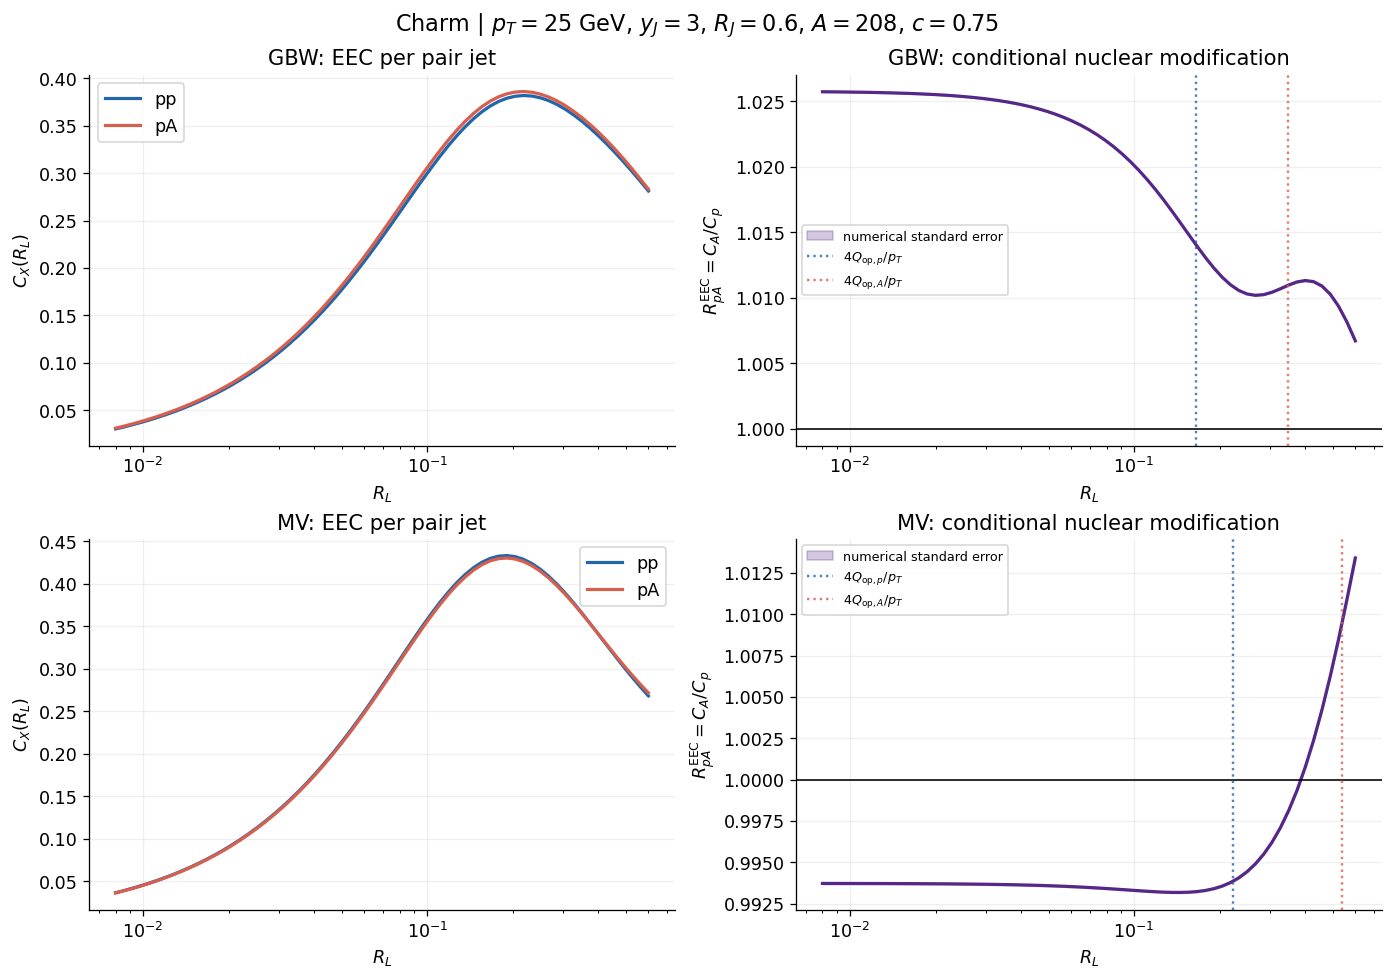

In [ ]:
fig, axes = plt.subplots(len(models), 2, figsize=(12, 4.2*len(models)), squeeze=False,
                         constrained_layout=True)
for row, model in enumerate(models):
    r = results[model]
    ax, ar = axes[row]
    for target, label, color in [('p', 'pp', '#2166ac'), ('A', 'pA', '#d6604d')]:
        value, error = r[target]['C'], r[target]['C_error']
        ax.plot(R_L, value, color=color, lw=2, label=label)
        ax.fill_between(R_L, value-error, value+error, color=color, alpha=.2)
    ax.set(xscale='log', xlabel=r'$R_L$', ylabel=r'$C_X(R_L)$', title=f'{model}: EEC per pair jet')
    ax.legend()
    ar.plot(R_L, r['ratio'], color='#542788', lw=2)
    ar.fill_between(R_L, r['ratio']-r['ratio_error'], r['ratio']+r['ratio_error'],
                    color='#542788', alpha=.25, label='numerical standard error')
    ar.axhline(1, color='black', lw=1)
    for target, color, name in [('p', '#2166ac', 'p'), ('A', '#d6604d', 'A')]:
        d = make_dipole(model, PHYSICS.Qs(target), PHYSICS.Lambda_QCD, NUMERICS.fft_n)
        angle = 4*d.Q_operational/PHYSICS.p_T
        if R_L[0] < angle < PHYSICS.R_J:
            ar.axvline(angle, color=color, ls=':', alpha=.8,
                       label=rf'$4Q_{{\mathrm{{op}},{name}}}/p_T$')
    ar.set(xscale='log', xlabel=r'$R_L$', ylabel=r'$R_{pA}^{\rm EEC}=C_A/C_p$',
           title=f'{model}: conditional nuclear modification')
    ar.legend(fontsize=8, loc='best')
fig.suptitle(rf'Charm | $p_T={PHYSICS.p_T:g}$ GeV, $y_J={PHYSICS.y_J:g}$, '
             rf'$R_J={PHYSICS.R_J:g}$, $A={PHYSICS.A:g}$, $c={PHYSICS.c_nuclear:g}$', fontsize=14)
fig.savefig(OUTPUT/'eec_and_nuclear_modification.png')
plt.show()

## 7. Independent disk integration and approximation diagnostics

For a separate check sample $k=bp_TR_J\sqrt{u}$ uniformly in the allowed transverse disk.
This bypasses the angular delta function and the numerical integration over $R$.
It must reproduce the denominator and $\langle b\rangle$ above.

The last columns measure the **unweighted pair-jet rate** coming from $z<0.1$ or $z>0.9$
and from $M_J^2/p_T^2>0.25$. They do not correct the leading-power approximation; they reveal
regions for which an exact-kinematics calculation or an explicit common constituent cut may matter.

In [10]:
disk_rows = []
for model, r in results.items():
    for target in ['p', 'A']:
        disk = disk_check(model, PHYSICS, NUMERICS, target)
        reference = r[target]
        delta = disk['denominator'].mean()/reference['denominator'].mean()-1
        mean_delta = disk['mean_weight'].mean()-reference['mean_weight'].mean()
        assert abs(delta) < .003, f'Disk normalization check failed: {model}, {target}, {delta}'
        assert abs(mean_delta) < .001
        assert disk['kernel_weight_in_asymptotic_tail'] < 1e-5
        disk_rows.append(dict(model=model, target=target,
            disk_denominator_relative_difference=delta,
            disk_mean_weight_difference=mean_delta,
            fraction_MJ2_over_PT2_gt_025=disk['fraction_MJ2_over_PT2_gt_025'],
            fraction_endpoint_z01=disk['fraction_endpoint_z01'],
            kernel_weight_in_asymptotic_tail=disk['kernel_weight_in_asymptotic_tail']))
disk_validation = pd.DataFrame(disk_rows)
display(disk_validation)
disk_validation.to_csv(OUTPUT/'disk_validation.csv', index=False)

,model,target,disk_denominator_relative_difference,disk_mean_weight_difference,fraction_MJ2_over_PT2_gt_025,fraction_endpoint_z01,kernel_weight_in_asymptotic_tail
0,GBW,p,-0.000007,-2.979919e-07,0.000123,0.060161,0.000000e+00
1,GBW,A,-0.000013,-3.345398e-07,0.000118,0.058059,0.000000e+00
2,MV,p,-0.000041,-2.400096e-06,0.000075,0.041580,2.825427e-14
3,MV,A,-0.000031,-2.078248e-06,0.000092,0.045137,1.265963e-15


## 8. Convergence and sampling-bias checks

Double the number of Sobol points; separately double the radial quadrature; change the MV
importance proposal width; and double the Hankel grid. Common random numbers make the
radial and Fourier comparisons especially sensitive to systematic integration errors.
Checks operate on representative angular points, including both ends of the scan.
The tolerances below concern numerical accuracy for this model study, not theoretical precision.

In [ ]:
convergence_rows = []
if RUN_CONVERGENCE:
    idx = np.unique(np.linspace(0, len(R_L)-1, 13, dtype=int))
    Rcheck = R_L[idx]
    for model, base in results.items():
        fine = solve_pair(model, PHYSICS, replace(NUMERICS, power=NUMERICS.power+1), Rcheck)
        difference = np.max(np.abs(fine['ratio']-base['ratio'][idx]))
        convergence_rows.append(dict(model=model, check='double Sobol points',
                                     max_abs_RpA_change=difference, tolerance=.0015))
        assert difference < .0015
    chosen = MODEL if MODEL in results else models[0]
    radial = solve_pair(chosen, PHYSICS, replace(NUMERICS, n_R=2*NUMERICS.n_R), Rcheck)
    difference = np.max(np.abs(radial['ratio']-results[chosen]['ratio'][idx]))
    convergence_rows.append(dict(model=chosen, check='double radial nodes',
                                 max_abs_RpA_change=difference, tolerance=2e-5))
    assert difference < 2e-5
    if 'MV' in results:
        alternative = solve_pair('MV', PHYSICS, NUMERICS, Rcheck, proposal_scale=1.5)
        difference = np.max(np.abs(alternative['ratio']-results['MV']['ratio'][idx]))
        convergence_rows.append(dict(model='MV', check='importance width x 1.5',
                                     max_abs_RpA_change=difference, tolerance=.0015))
        assert difference < .0015
        fft_error = []
        for target in ['p', 'A']:
            d0 = make_dipole('MV', PHYSICS.Qs(target), PHYSICS.Lambda_QCD, NUMERICS.fft_n)
            d1 = make_dipole('MV', PHYSICS.Qs(target), PHYSICS.Lambda_QCD, 2*NUMERICS.fft_n)
            qtest = np.geomspace(.01*d0.Qs, max(4*PHYSICS.p_T, 20*d0.Qs), 1000)
            fft_error.append(np.max(np.abs(d1.F(qtest)/d0.F(qtest)-1)))
        print(f'MV Fourier-table refinement, max relative F change: {max(fft_error):.3g}')
        assert max(fft_error) < 2e-5
    convergence = pd.DataFrame(convergence_rows)
    display(convergence)
    convergence.to_csv(OUTPUT/'convergence.csv', index=False)
else:
    print('Convergence checks skipped by the user setting RUN_CONVERGENCE=False.')

MV Fourier-table refinement, max relative F change: 1.38e-09


,model,check,max_abs_RpA_change,tolerance
0,GBW,double Sobol points,1.671702e-05,0.00150
1,MV,double Sobol points,4.555655e-05,0.00150
2,MV,double radial nodes,3.330669e-16,0.00002
3,MV,importance width x 1.5,6.991752e-05,0.00150


## 9. Transverse-momentum and nuclear-scale scans

The moderate-$p_T$ curves test sensitivity; the larger-$p_T$ curve tests how it weakens or moves.
Changing $p_T$ also changes $x_t$ and therefore $Q_s$. The geometry scan varies $c$ only in the
nuclear $Q_s^2$; the proton baseline is the same. These model variations are not numerical errors.
The inexpensive scan uses fewer points than the main calculation and retains its own error bands.

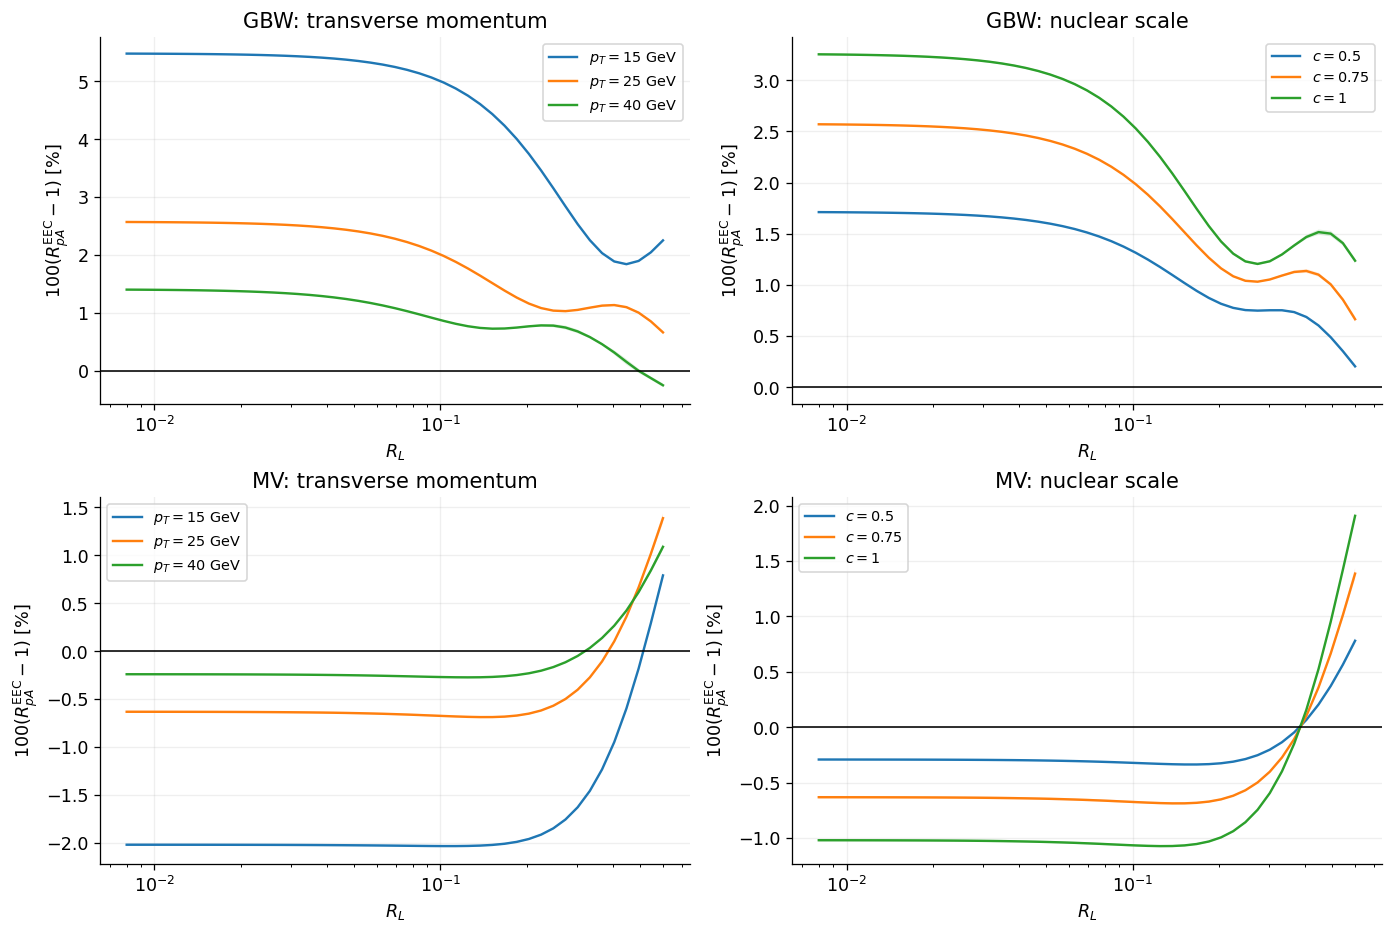

In [12]:
scan_results = {}
if RUN_PARAMETER_SCAN:
    scan_num = replace(NUMERICS, power=max(15, NUMERICS.power-2), repeats=6, n_R=40)
    scan_R = np.geomspace(R_L[0], PHYSICS.R_J, 45)
    P_values = sorted(set([15.0, PHYSICS.p_T, 40.0]))
    c_values = sorted(set([0.5, PHYSICS.c_nuclear, 1.0]))
    fig, axes = plt.subplots(len(models), 2, figsize=(12, 4*len(models)), squeeze=False,
                             constrained_layout=True)
    for row, model in enumerate(models):
        for P in P_values:
            cfg = replace(PHYSICS, p_T=P)
            r = solve_pair(model, cfg, scan_num, scan_R)
            scan_results[f'{model}_pT_{P:g}'] = r
            axes[row, 0].plot(scan_R, 100*(r['ratio']-1), label=rf'$p_T={P:g}$ GeV')
            axes[row, 0].fill_between(scan_R, 100*(r['ratio']-1-r['ratio_error']),
                                      100*(r['ratio']-1+r['ratio_error']), alpha=.15)
        for c in c_values:
            r = solve_pair(model, replace(PHYSICS, c_nuclear=c), scan_num, scan_R)
            scan_results[f'{model}_c_{c:g}'] = r
            axes[row, 1].plot(scan_R, 100*(r['ratio']-1), label=rf'$c={c:g}$')
            axes[row, 1].fill_between(scan_R, 100*(r['ratio']-1-r['ratio_error']),
                                      100*(r['ratio']-1+r['ratio_error']), alpha=.15)
        for column in range(2):
            ax = axes[row, column]
            ax.axhline(0, color='black', lw=1)
            ax.set(xscale='log', xlabel=r'$R_L$', ylabel=r'$100(R_{pA}^{\rm EEC}-1)$ [%]',
                   title=f'{model}: '+('transverse momentum' if column == 0 else 'nuclear scale'))
            ax.legend(fontsize=9)
    fig.savefig(OUTPUT/'parameter_scans.png')
    plt.show()
    for name, r in scan_results.items():
        result_frame(r).to_csv(OUTPUT/f'scan_{name}.csv', index=False)

## 10. Inspect the dipoles and save the run

The momentum-space panel exposes MV's power tail and GBW's Gaussian falloff. A conditional EEC alone
cannot establish saturation: compare dipole models, geometry, mass and kinematic choices, and
ultimately an appropriate dilute baseline and a more complete phenomenological calculation.
The notebook computes the requested full saturated-model results without manufacturing such a baseline.

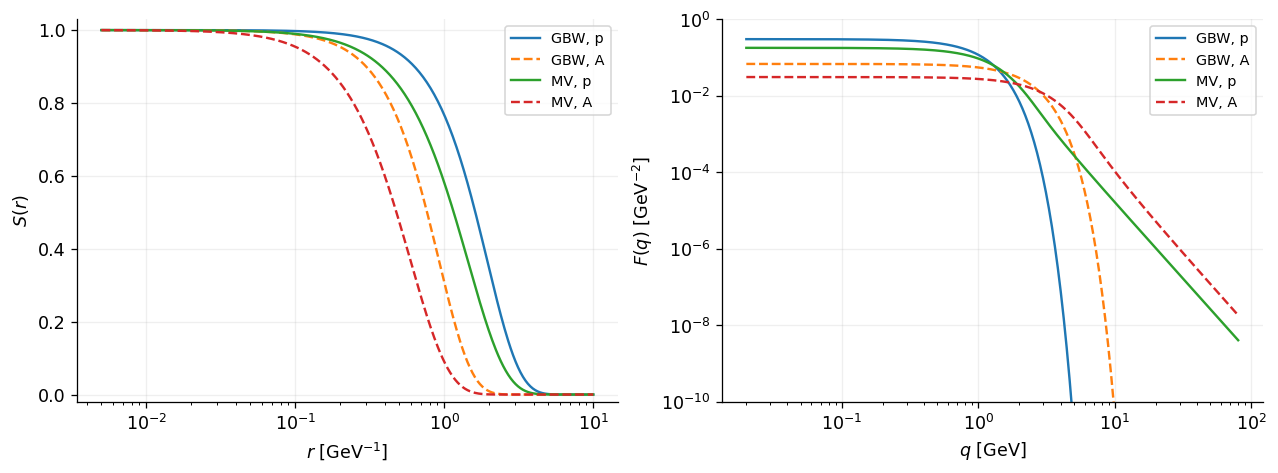

Saved tables, plots and run metadata in: /Users/carloslamasrodriguez/Desktop/UCLA_Project/InJetEECs/eec_results


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
rr = np.geomspace(.005, 10, 400)
qq = np.geomspace(.02, 80, 500)
for model in models:
    for target, style in [('p', '-'), ('A', '--')]:
        d = make_dipole(model, PHYSICS.Qs(target), PHYSICS.Lambda_QCD, NUMERICS.fft_n)
        axes[0].semilogx(rr, d.S(rr), ls=style, label=f'{model}, {target}')
        axes[1].loglog(qq, d.F(qq), ls=style, label=f'{model}, {target}')
axes[0].set(xlabel=r'$r$ [GeV$^{-1}$]', ylabel=r'$S(r)$', ylim=(-.02, 1.03))
axes[1].set(xlabel=r'$q$ [GeV]', ylabel=r'$F(q)$ [GeV$^{-2}$]', ylim=(1e-10, 1))
axes[0].legend(fontsize=9)
axes[1].legend(fontsize=9)
fig.savefig(OUTPUT/'dipole_models.png')
plt.show()
metadata = dict(physics=asdict(PHYSICS), numerics=asdict(NUMERICS), models=models,
                numpy=np.__version__, scipy=scipy.__version__,
                observable='EEC per QQbar-containing jet, fixed yJ and pT; RpA=CA/Cp',
                assumptions=['leading collinear and forward energy approximations',
                             'massless-jet x_p and x_t', 'deterministic dipole product',
                             'same GBW Qs(x) prescription for MV; no BK evolution'])
(OUTPUT/'run_metadata.json').write_text(json.dumps(metadata, indent=2))
print('Saved tables, plots and run metadata in:', OUTPUT.resolve())

## References and extensions

- **User notes:** *In_jet_EECs-10.pdf*, Eqs. (29), (37)–(44), (47). The notebook follows the
  conditional pair-jet normalization clarified in this conversation.
- [Golec-Biernat and Wüsthoff, hep-ph/9807513](https://arxiv.org/abs/hep-ph/9807513):
  original saturation-model context. Numerical inputs here are the values in the notes.
- [Lappi and Mäntysaari, arXiv:1309.6963, Eq. (6)](https://arxiv.org/abs/1309.6963):
  MV-type coordinate-space parametrization. This notebook uses $\gamma=e_c=1$ and the requested
  GBW estimate of $Q_s(x)$, rather than that paper's fitted/evolved parameters.
- [SciPy FFTLog convention](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fht.html)
  and [scrambled Sobol integration](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.qmc.Sobol.html).

Useful next studies: use `m_Q=4.5` for a bottom comparison; repeat with `R_J=0.4`;
compare `z_min=0` and `0.1` with the same cuts in both integrals; scan `y_J` at fixed $p_T$;
or register a BK-evolved dipole in `DIPOLE_MODELS`. These change physics assumptions or the
selected observable, so rerun the diagnostics. Exact massive jet kinematics would require
retaining the internal-variable dependence of the PDFs and the exact angular measurement.